# An?lise de Utiliza??o de Recursos

Este notebook analisa o comportamento de recursos do experimento **soft-prompt com Gemma 3 270M**.

Objetivos:
- entender como CPU, RAM, mem?ria GPU e tempo evolu?ram ao longo do treino e da infer?ncia
- verificar se h? sinais de satura??o, gargalos ou overfitting
- produzir figuras e observa??es que ajudem na escrita do artigo


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'results').exists() and (PROJECT_ROOT.parent / 'results').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / 'results' / 'notebook_metrics'
RUN_PREFIX = 'obd_soft_prompt_gemma_3_270m'

TRAIN_SAMPLES_PATH = METRICS_DIR / f'{RUN_PREFIX}_train_samples.csv'
TRAIN_SUMMARY_PATH = METRICS_DIR / f'{RUN_PREFIX}_train_summary.json'
INFER_SAMPLES_PATH = METRICS_DIR / f'{RUN_PREFIX}_inference_samples.csv'
INFER_SUMMARY_PATH = METRICS_DIR / f'{RUN_PREFIX}_inference_summary.json'

for path in [TRAIN_SAMPLES_PATH, TRAIN_SUMMARY_PATH, INFER_SAMPLES_PATH, INFER_SUMMARY_PATH]:
    print(path, 'FOUND' if path.exists() else 'MISSING')


c:\Users\Morsinaldo\Desktop\OpenTSLM\results\notebook_metrics\obd_soft_prompt_gemma_3_270m_train_samples.csv FOUND
c:\Users\Morsinaldo\Desktop\OpenTSLM\results\notebook_metrics\obd_soft_prompt_gemma_3_270m_train_summary.json FOUND
c:\Users\Morsinaldo\Desktop\OpenTSLM\results\notebook_metrics\obd_soft_prompt_gemma_3_270m_inference_samples.csv FOUND
c:\Users\Morsinaldo\Desktop\OpenTSLM\results\notebook_metrics\obd_soft_prompt_gemma_3_270m_inference_summary.json FOUND


In [3]:
def bytes_to_gib(series: pd.Series) -> pd.Series:
    return series / (1024 ** 3)


def load_summary(path: Path) -> dict:
    return json.loads(path.read_text(encoding='utf-8'))


train_df = pd.read_csv(TRAIN_SAMPLES_PATH)
infer_df = pd.read_csv(INFER_SAMPLES_PATH)
train_summary = load_summary(TRAIN_SUMMARY_PATH)
infer_summary = load_summary(INFER_SUMMARY_PATH)

for df in [train_df, infer_df]:
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True, errors='coerce')
    df['elapsed_min'] = df['elapsed_s'] / 60.0

train_epoch = train_df[train_df['phase'] == 'epoch_end'].copy()
train_steps = train_df[train_df['phase'] == 'train_step'].copy()
train_checkpoints = train_df[train_df['phase'] == 'checkpoint_saved'].copy()
train_background = train_df[train_df['phase'].isin(['sample', 'train_step', 'epoch_end', 'checkpoint_saved', 'finished'])].copy()

infer_steps = infer_df[infer_df['phase'] == 'inference_step'].copy()
infer_background = infer_df[infer_df['phase'].isin(['sample', 'inference_step', 'finished'])].copy()

for df in [train_df, train_background, infer_df, infer_background]:
    for col in ['process_rss_bytes', 'system_ram_used_bytes', 'cuda_0_memory_allocated_bytes', 'cuda_0_memory_reserved_bytes', 'cuda_0_max_memory_allocated_bytes']:
        if col in df.columns:
            df[col.replace('_bytes', '_gib')] = bytes_to_gib(df[col])

print('train rows:', len(train_df), '| epoch rows:', len(train_epoch), '| train steps:', len(train_steps))
print('inference rows:', len(infer_df), '| inference steps:', len(infer_steps))


train rows: 1769 | epoch rows: 14 | train steps: 812
inference rows: 840 | inference steps: 39


## Resumo r?pido

A tabela abaixo junta os n?meros principais de treino e infer?ncia.

In [4]:
overview = pd.DataFrame([
    {
        'stage': 'train',
        'duration_s': train_summary['total_duration_s'],
        'samples_logged': train_summary['sample_count'],
        'epochs': int(train_epoch['epoch'].nunique()),
        'best_val_loss': float(train_epoch['val_loss'].min()),
        'best_epoch': int(train_epoch.loc[train_epoch['val_loss'].idxmin(), 'epoch']),
        'peak_gpu_alloc_gib': train_summary.get('cuda_0_max_memory_allocated_bytes_max', np.nan) / (1024 ** 3),
        'peak_gpu_reserved_gib': train_summary.get('cuda_0_max_memory_reserved_bytes_max', np.nan) / (1024 ** 3),
        'peak_process_rss_gib': train_summary.get('process_rss_bytes_max', np.nan) / (1024 ** 3),
        'mean_step_time_s': float(train_steps['step_duration_s'].dropna().mean()),
    },
    {
        'stage': 'inference',
        'duration_s': infer_summary['total_duration_s'],
        'samples_logged': infer_summary['sample_count'],
        'epochs': np.nan,
        'best_val_loss': np.nan,
        'best_epoch': np.nan,
        'peak_gpu_alloc_gib': infer_summary.get('cuda_0_max_memory_allocated_bytes_max', np.nan) / (1024 ** 3),
        'peak_gpu_reserved_gib': infer_summary.get('cuda_0_max_memory_reserved_bytes_max', np.nan) / (1024 ** 3),
        'peak_process_rss_gib': infer_summary.get('process_rss_bytes_max', np.nan) / (1024 ** 3),
        'mean_step_time_s': float(infer_steps['inference_latency_s'].dropna().mean()),
    },
])
overview


,stage,duration_s,samples_logged,epochs,best_val_loss,best_epoch,peak_gpu_alloc_gib,peak_gpu_reserved_gib,peak_process_rss_gib,mean_step_time_s
0,train,590.626400,1769,14.0,2.298066,11.0,7.398594,17.271484,12.577839,0.657493
1,inference,403.389596,840,NaN,NaN,NaN,0.623293,9.617188,4.337124,10.341808


## Treinamento: desempenho do modelo

Primeiro verificamos se o comportamento do `train_loss` e `val_loss` sugere aprendizado est?vel e onde o treinamento deixou de melhorar.

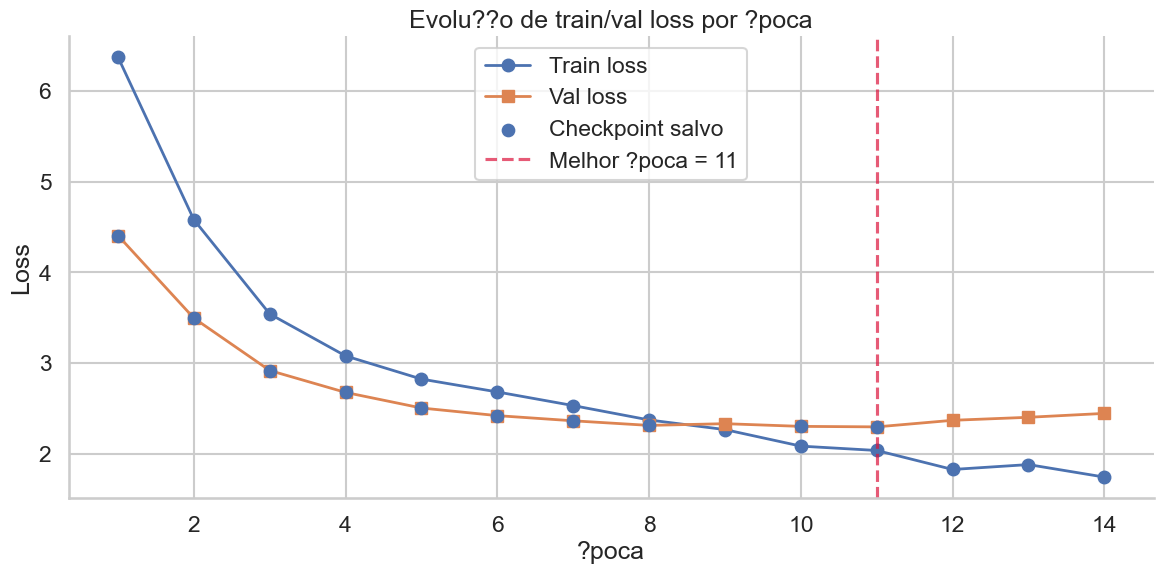

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_epoch['epoch'], train_epoch['train_loss'], marker='o', label='Train loss', linewidth=2)
ax.plot(train_epoch['epoch'], train_epoch['val_loss'], marker='s', label='Val loss', linewidth=2)
if not train_checkpoints.empty:
    ax.scatter(train_checkpoints['epoch'], train_checkpoints['best_val'], s=70, label='Checkpoint salvo', zorder=5)

best_row = train_epoch.loc[train_epoch['val_loss'].idxmin()]
ax.axvline(best_row['epoch'], color='crimson', linestyle='--', alpha=0.7, label=f"Melhor ?poca = {int(best_row['epoch'])}")
ax.set_title('Evolu??o de train/val loss por ?poca')
ax.set_xlabel('?poca')
ax.set_ylabel('Loss')
ax.legend()
plt.show()


## Treinamento: uso de recursos ao longo do tempo

Aqui observamos a evolu??o temporal dos principais recursos. A compara??o entre mem?ria alocada e reservada da GPU ajuda a entender fragmenta??o/caching do PyTorch.

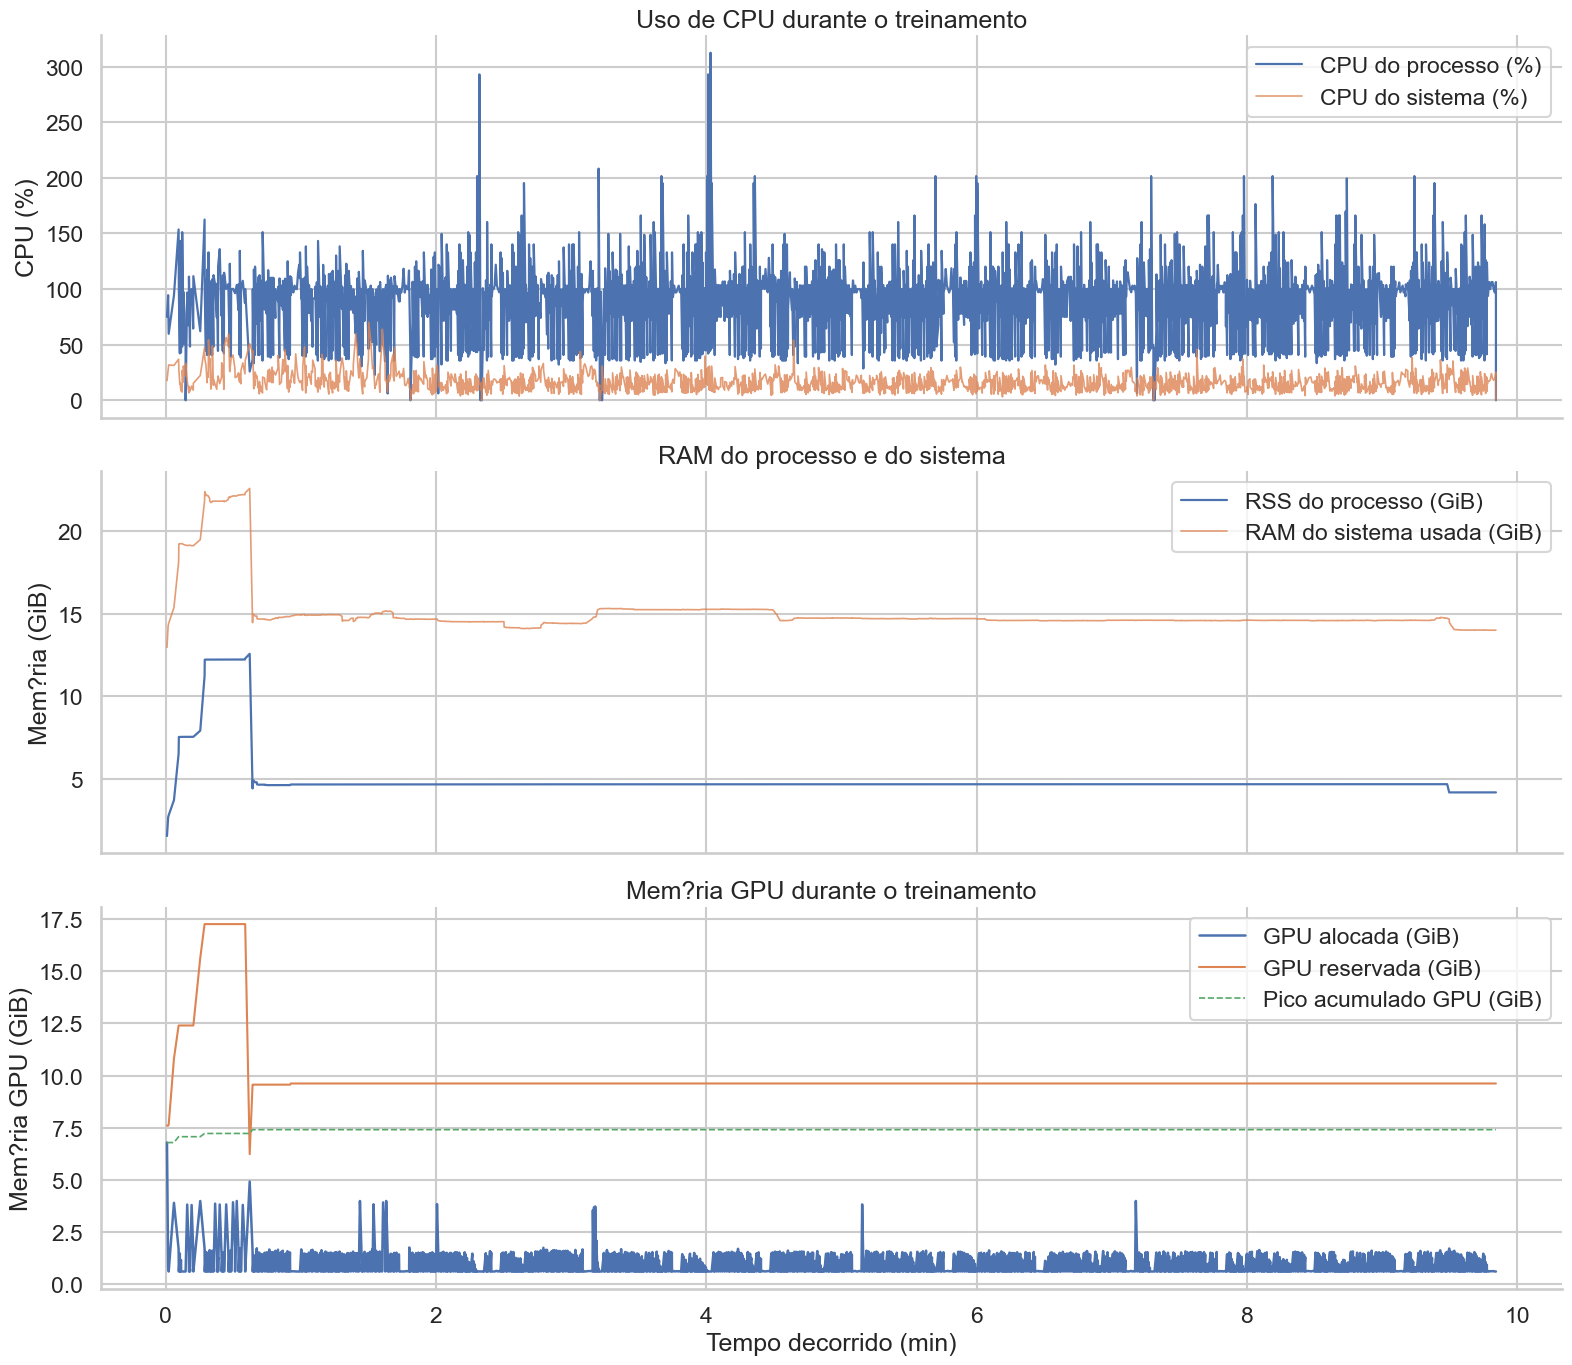

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

axes[0].plot(train_background['elapsed_min'], train_background['process_cpu_percent'], label='CPU do processo (%)', linewidth=1.6)
axes[0].plot(train_background['elapsed_min'], train_background['system_cpu_percent'], label='CPU do sistema (%)', linewidth=1.2, alpha=0.8)
axes[0].set_ylabel('CPU (%)')
axes[0].set_title('Uso de CPU durante o treinamento')
axes[0].legend()

axes[1].plot(train_background['elapsed_min'], train_background['process_rss_gib'], label='RSS do processo (GiB)', linewidth=1.6)
axes[1].plot(train_background['elapsed_min'], train_background['system_ram_used_gib'], label='RAM do sistema usada (GiB)', linewidth=1.2, alpha=0.8)
axes[1].set_ylabel('Mem?ria (GiB)')
axes[1].set_title('RAM do processo e do sistema')
axes[1].legend()

axes[2].plot(train_background['elapsed_min'], train_background['cuda_0_memory_allocated_gib'], label='GPU alocada (GiB)', linewidth=1.8)
axes[2].plot(train_background['elapsed_min'], train_background['cuda_0_memory_reserved_gib'], label='GPU reservada (GiB)', linewidth=1.5)
axes[2].plot(train_background['elapsed_min'], train_background['cuda_0_max_memory_allocated_gib'], label='Pico acumulado GPU (GiB)', linewidth=1.2, linestyle='--')
axes[2].set_xlabel('Tempo decorrido (min)')
axes[2].set_ylabel('Mem?ria GPU (GiB)')
axes[2].set_title('Mem?ria GPU durante o treinamento')
axes[2].legend()

plt.tight_layout()
plt.show()


## Treinamento: tempo por passo e gradiente

Esses gr?ficos ajudam a ver estabilidade do custo computacional por batch e poss?veis picos de gradiente.

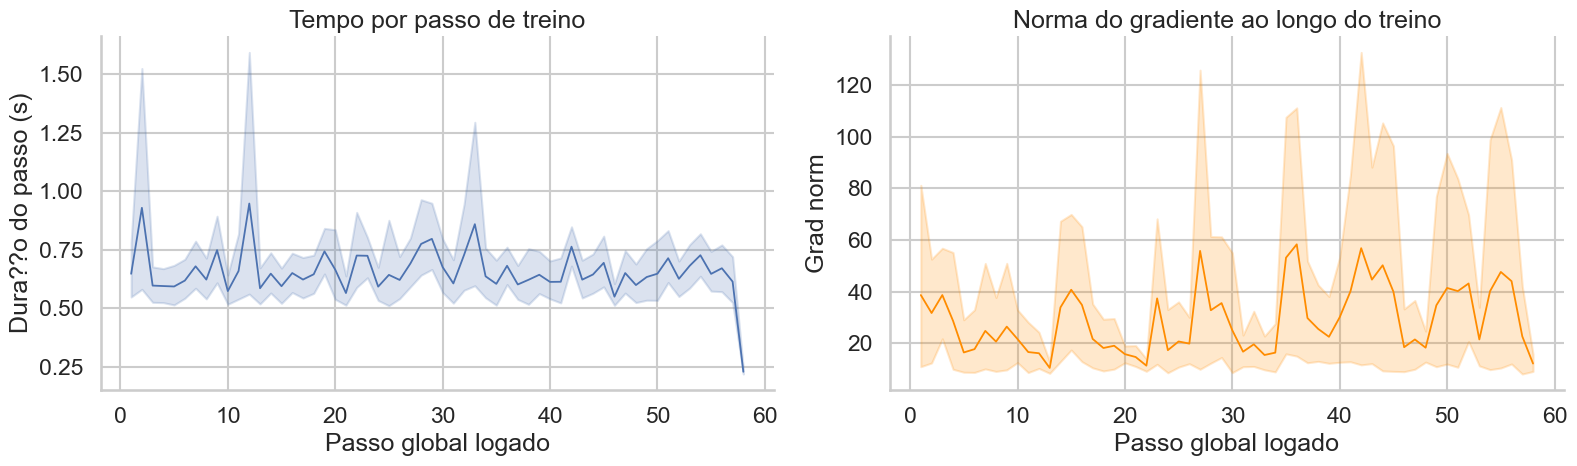

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=train_steps, x='step', y='step_duration_s', ax=axes[0], linewidth=1.3)
axes[0].set_title('Tempo por passo de treino')
axes[0].set_xlabel('Passo global logado')
axes[0].set_ylabel('Dura??o do passo (s)')

sns.lineplot(data=train_steps, x='step', y='grad_norm', ax=axes[1], linewidth=1.3, color='darkorange')
axes[1].set_title('Norma do gradiente ao longo do treino')
axes[1].set_xlabel('Passo global logado')
axes[1].set_ylabel('Grad norm')

plt.tight_layout()
plt.show()


## Infer?ncia: lat?ncia por amostra

Aqui avaliamos dispers?o, tend?ncia e distribui??o das lat?ncias.

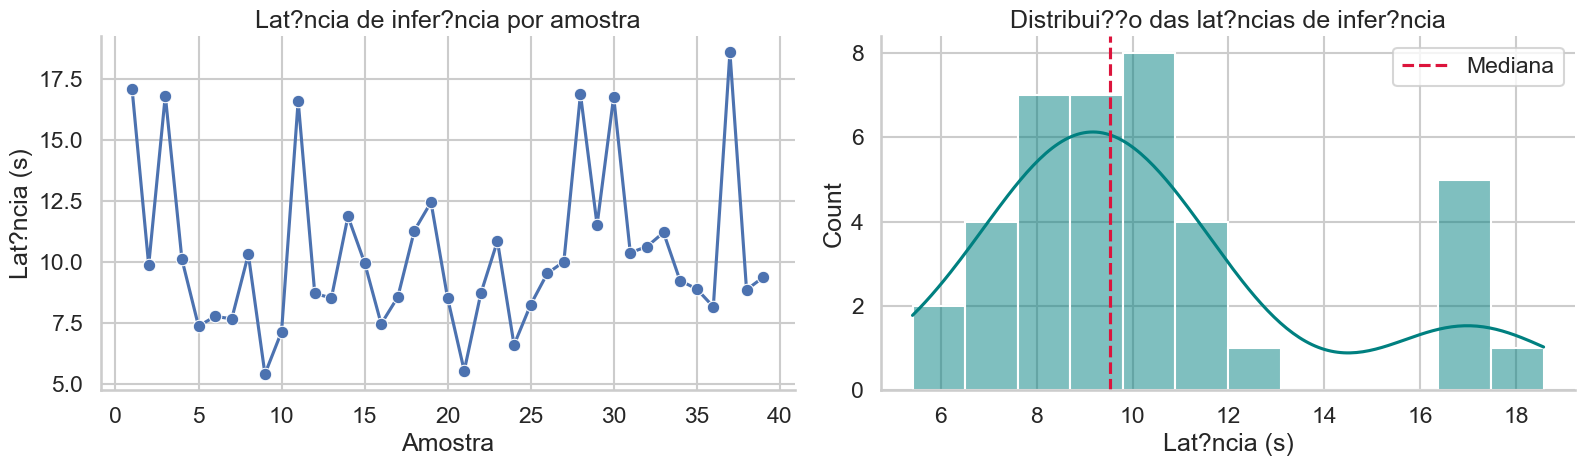

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=infer_steps, x='step', y='inference_latency_s', marker='o', ax=axes[0])
axes[0].set_title('Lat?ncia de infer?ncia por amostra')
axes[0].set_xlabel('Amostra')
axes[0].set_ylabel('Lat?ncia (s)')

sns.histplot(infer_steps['inference_latency_s'], bins=12, kde=True, ax=axes[1], color='teal')
axes[1].axvline(infer_steps['inference_latency_s'].median(), color='crimson', linestyle='--', label='Mediana')
axes[1].set_title('Distribui??o das lat?ncias de infer?ncia')
axes[1].set_xlabel('Lat?ncia (s)')
axes[1].legend()

plt.tight_layout()
plt.show()


## Infer?ncia: recursos ao longo do tempo

Esse painel mostra se a infer?ncia ficou est?vel ou se houve drift de consumo durante a gera??o das respostas.

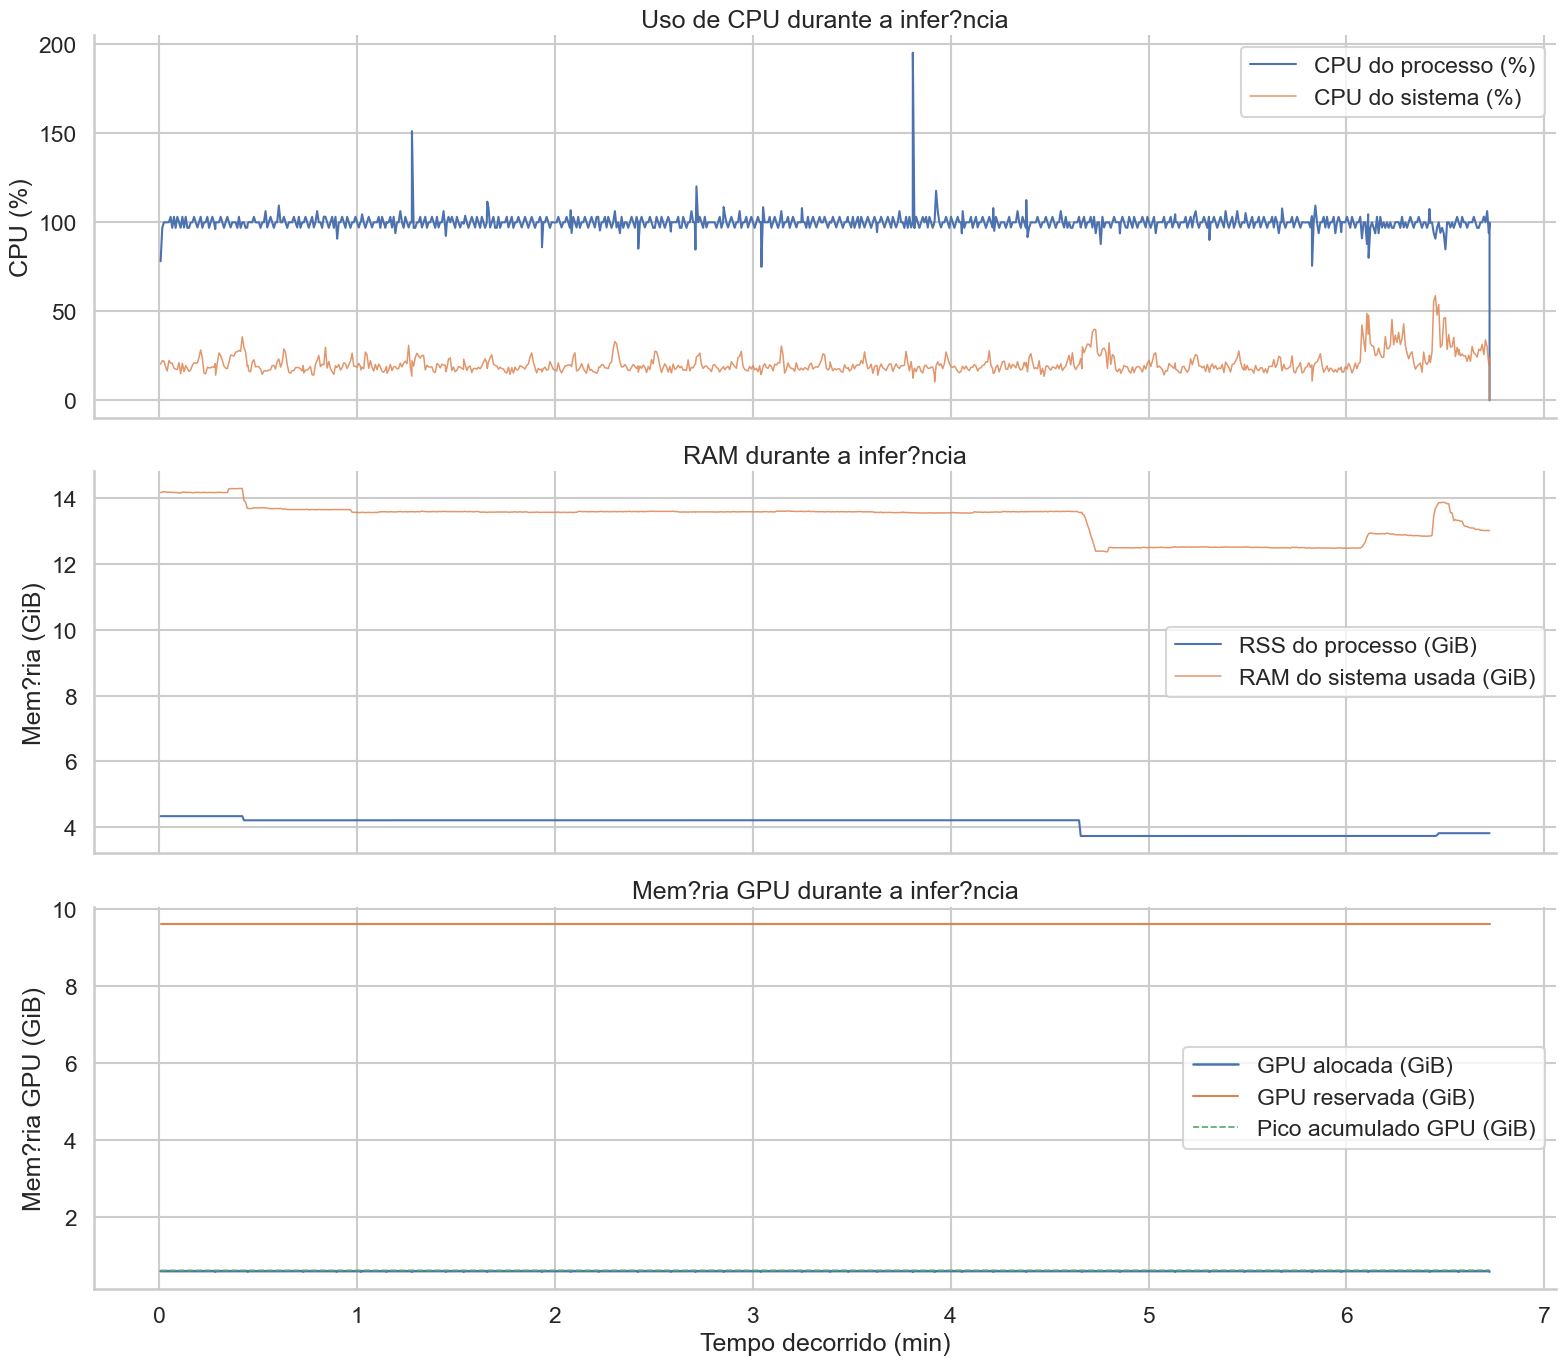

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

axes[0].plot(infer_background['elapsed_min'], infer_background['process_cpu_percent'], label='CPU do processo (%)', linewidth=1.5)
axes[0].plot(infer_background['elapsed_min'], infer_background['system_cpu_percent'], label='CPU do sistema (%)', linewidth=1.1, alpha=0.85)
axes[0].set_ylabel('CPU (%)')
axes[0].set_title('Uso de CPU durante a infer?ncia')
axes[0].legend()

axes[1].plot(infer_background['elapsed_min'], infer_background['process_rss_gib'], label='RSS do processo (GiB)', linewidth=1.5)
axes[1].plot(infer_background['elapsed_min'], infer_background['system_ram_used_gib'], label='RAM do sistema usada (GiB)', linewidth=1.1, alpha=0.85)
axes[1].set_ylabel('Mem?ria (GiB)')
axes[1].set_title('RAM durante a infer?ncia')
axes[1].legend()

axes[2].plot(infer_background['elapsed_min'], infer_background['cuda_0_memory_allocated_gib'], label='GPU alocada (GiB)', linewidth=1.8)
axes[2].plot(infer_background['elapsed_min'], infer_background['cuda_0_memory_reserved_gib'], label='GPU reservada (GiB)', linewidth=1.5)
axes[2].plot(infer_background['elapsed_min'], infer_background['cuda_0_max_memory_allocated_gib'], label='Pico acumulado GPU (GiB)', linewidth=1.2, linestyle='--')
axes[2].set_xlabel('Tempo decorrido (min)')
axes[2].set_ylabel('Mem?ria GPU (GiB)')
axes[2].set_title('Mem?ria GPU durante a infer?ncia')
axes[2].legend()

plt.tight_layout()
plt.show()


## Leitura autom?tica dos resultados

A c?lula abaixo resume os achados principais do run. Ela ? ?til para virar texto de artigo, relat?rio ou legenda de figura.

In [10]:
best_epoch = int(train_epoch.loc[train_epoch['val_loss'].idxmin(), 'epoch'])
best_val = float(train_epoch['val_loss'].min())
last_val = float(train_epoch['val_loss'].iloc[-1])
overfit_gap = last_val - best_val

train_peak_alloc = train_summary.get('cuda_0_max_memory_allocated_bytes_max', np.nan) / (1024 ** 3)
train_peak_reserved = train_summary.get('cuda_0_max_memory_reserved_bytes_max', np.nan) / (1024 ** 3)
infer_peak_alloc = infer_summary.get('cuda_0_max_memory_allocated_bytes_max', np.nan) / (1024 ** 3)

lat = infer_steps['inference_latency_s'].dropna()
step_time = train_steps['step_duration_s'].dropna()

insights = [
    f'O melhor desempenho de valida??o ocorreu na ?poca {best_epoch}, com val_loss = {best_val:.4f}.',
    f'O treino foi interrompido ap?s {int(train_epoch["epoch"].max())} ?pocas; a val_loss final ficou {overfit_gap:.4f} acima do melhor valor, sugerindo perda de generaliza??o depois do pico.',
    f'O pico de mem?ria GPU no treino foi de {train_peak_alloc:.2f} GiB alocados e {train_peak_reserved:.2f} GiB reservados.',
    f'Na infer?ncia, o pico de mem?ria GPU alocada foi de {infer_peak_alloc:.2f} GiB.',
    f'A lat?ncia de infer?ncia teve m?dia de {lat.mean():.2f} s, mediana de {lat.median():.2f} s e p95 de {lat.quantile(0.95):.2f} s por amostra.',
    f'O tempo m?dio por passo de treino foi de {step_time.mean():.2f} s.',
]

if 'disk_percent' in train_df.columns:
    max_disk = float(train_df['disk_percent'].dropna().max())
    insights.append(f'O uso de disco chegou a {max_disk:.1f}% do volume monitorado, ent?o vale tratar esse recurso como potencial risco operacional.')

if 'gpu_0_utilization_percent' not in train_df.columns and 'gpu_0_utilization_percent' not in infer_df.columns:
    insights.append('Este run n?o traz utiliza??o percentual da GPU via NVML; a an?lise de GPU ficou baseada em mem?ria e tempo, n?o em occupancy.')

for item in insights:
    print('-', item)


- O melhor desempenho de valida??o ocorreu na ?poca 11, com val_loss = 2.2981.
- O treino foi interrompido ap?s 14 ?pocas; a val_loss final ficou 0.1485 acima do melhor valor, sugerindo perda de generaliza??o depois do pico.
- O pico de mem?ria GPU no treino foi de 7.40 GiB alocados e 17.27 GiB reservados.
- Na infer?ncia, o pico de mem?ria GPU alocada foi de 0.62 GiB.
- A lat?ncia de infer?ncia teve m?dia de 10.34 s, mediana de 9.52 s e p95 de 16.89 s por amostra.
- O tempo m?dio por passo de treino foi de 0.66 s.
- O uso de disco chegou a 99.8% do volume monitorado, ent?o vale tratar esse recurso como potencial risco operacional.
- Este run n?o traz utiliza??o percentual da GPU via NVML; a an?lise de GPU ficou baseada em mem?ria e tempo, n?o em occupancy.
